<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Grupo%20M%C3%A9xico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [215]:
!pip install pmdarima

In [216]:
!pip install arch

In [217]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error
from arch import arch_model
from sklearn.metrics import mean_absolute_percentage_error

#Grupo México

In [306]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01')

/tmp/ipykernel_11741/2329736698.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [307]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [308]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Análisis de la serie

##Medias Móviles

###Media Móvil Simple

In [221]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

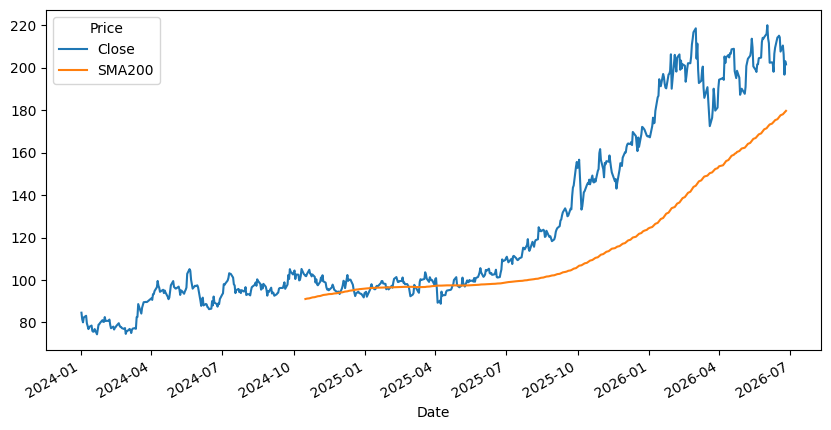

In [222]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [223]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [224]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

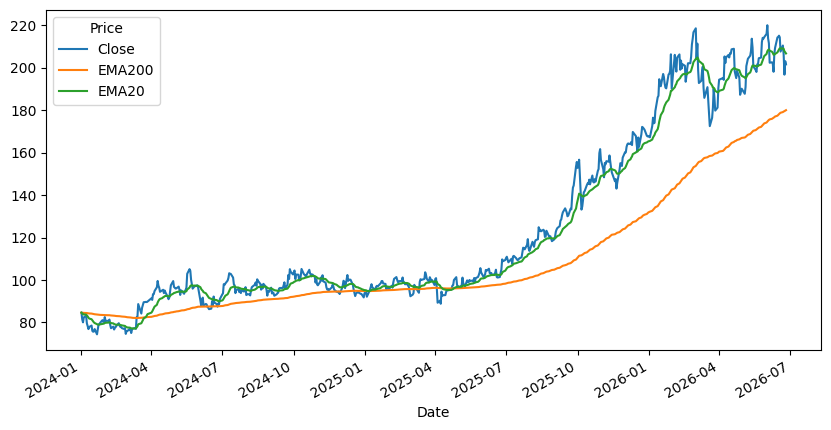

In [225]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

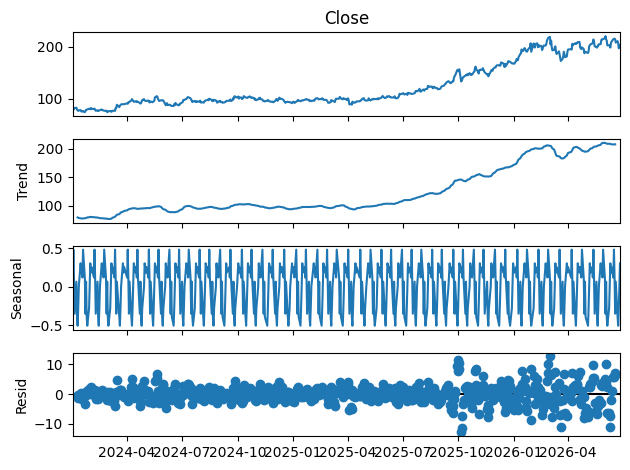

In [226]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

###Modelo Multiplicativo

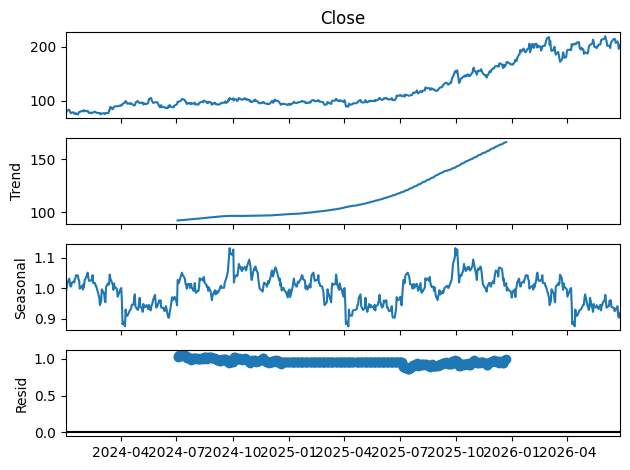

In [227]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()

#Volatilidad

##Desviación Estándar

In [228]:
#Obtener datos
precios = df['Close']

In [229]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
                ...   
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
2026-06-26   -0.007566
Name: Rendimientos_Log, Length: 622, dtype: float64


In [230]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
2026-06-26   -0.007566
Name: Rendimientos_Log, Length: 621, dtype: float64


In [231]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()

In [232]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)

In [233]:
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [234]:
print(f"Volatilidad diaria: {volatilidad_diaria:.4f} = {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {volatilidad_anual:.4f} = {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 0.0223 = 2.2301 %
Volatilidad anualizada: 0.3540 = 35.4015 %


##Average True Range

In [235]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [236]:
print(high_low)

Date
2024-01-03     3.811027
2024-01-04     2.643276
2024-01-05     6.381883
2024-01-08     2.570863
2024-01-09     4.200276
                ...    
2026-06-22     7.779999
2026-06-23     9.880005
2026-06-24    10.000000
2026-06-25     8.190002
2026-06-26     5.139999
Length: 621, dtype: float64


In [237]:
print(high_close)

Date
2024-01-03         NaN
2024-01-04    0.117674
2024-01-05    6.046956
2024-01-08    0.887118
2024-01-09    0.253460
                ...   
2026-06-22    3.880005
2026-06-23    1.550003
2026-06-24    1.100006
2026-06-25    8.050003
2026-06-26    1.119995
Length: 621, dtype: float64


In [238]:
print(low_close)

Date
2024-01-03          NaN
2024-01-04     2.525602
2024-01-05     0.334927
2024-01-08     1.683744
2024-01-09     3.946816
                ...    
2026-06-22     3.899994
2026-06-23    11.430008
2026-06-24    11.100006
2026-06-25     0.139999
2026-06-26     4.020004
Length: 621, dtype: float64


In [239]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [240]:
print(true_range)

Date
2024-01-03     3.811027
2024-01-04     2.643276
2024-01-05     6.381883
2024-01-08     2.570863
2024-01-09     4.200276
                ...    
2026-06-22     7.779999
2026-06-23    11.430008
2026-06-24    11.100006
2026-06-25     8.190002
2026-06-26     5.139999
Length: 621, dtype: float64


In [241]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [242]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [243]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price             High         Low       Close  ATR_Calculado
Date                                                         
2026-06-22  211.380005  203.600006  210.360001       7.561625
2026-06-23  208.809998  198.929993  206.100006       7.837938
2026-06-24  205.000000  195.000000  196.639999       8.070943
2026-06-25  204.690002  196.500000  202.990005       8.079447
2026-06-26  204.110001  198.970001  201.460007       7.869486


In [244]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: {atr_diario:.4f}")

ATR diario: 4.2961


In [245]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: {atr_anualizado:.4f}")

ATR anualizado: 68.1979


#Parámetros (p,d,q)

##Precios Diferenciados

###Serie Estacionaria


In [246]:
#Obtener datos
precios = df['Close']

In [247]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [248]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: 0.2532
Valor p: 0.9751
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9750920610814684)

####Diferenciando

In [249]:
# Calcular la primera diferencia del precio de cierre (columna 'Close')
differenced_prices = precios.diff().dropna()

In [250]:
# Mostrar los primeros elementos de la serie diferenciada
print(differenced_prices.head())

Date
2024-01-04   -1.412170
2024-01-05    2.308350
2024-01-08    0.778488
2024-01-09   -3.611877
2024-01-10   -1.213013
Name: Close, dtype: float64


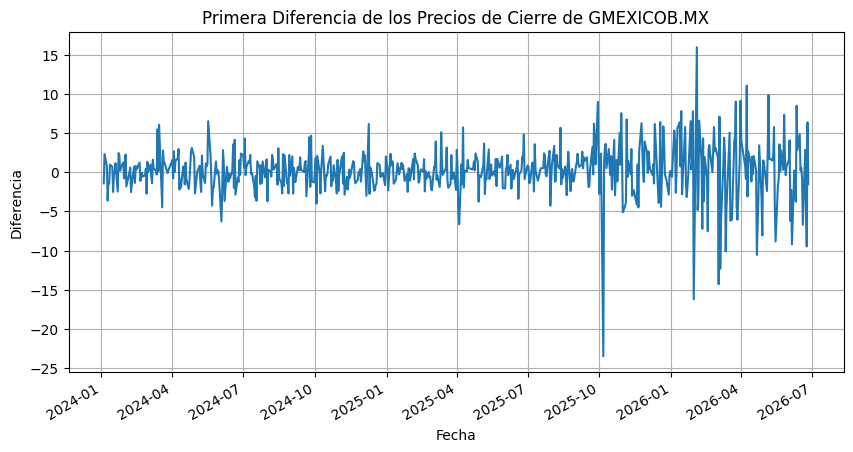

In [251]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
differenced_prices.plot()
plt.title(f'Primera Diferencia de los Precios de Cierre de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

In [252]:
# Ejecutar prueba en serie diferenciada
probar_estacionariedad(differenced_prices, "Serie diferenciada")


--- Prueba ADF para: Serie diferenciada ---
Estadístico de Dickey-Fuller: -11.4592
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


np.float64(5.6098967536949175e-21)

###Función de Autocorrelación

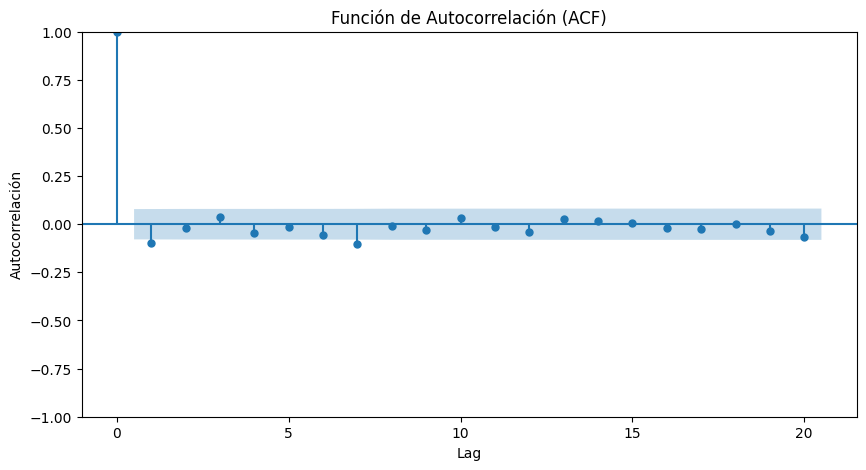

In [253]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(differenced_prices, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial (PACF)

<Figure size 1000x500 with 0 Axes>

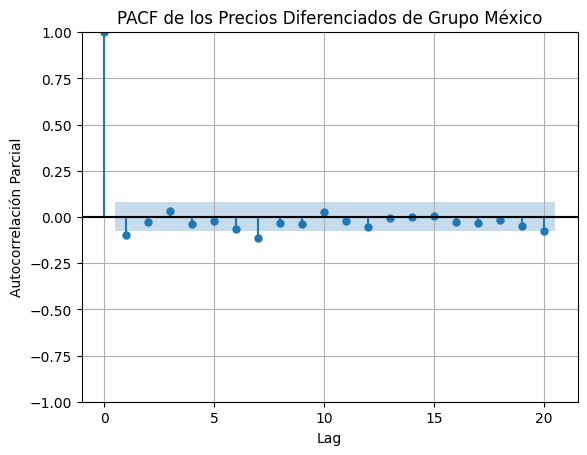

In [254]:
#Graficar la PACF
plt.figure(figsize=(10, 5))
plot_pacf(differenced_prices, lags=20, method='ywm') # method='ywm' es Yule-Walker modificado
plt.title('PACF de los Precios Diferenciados de Grupo México')
plt.xlabel('Lag')
plt.ylabel('Autocorrelación Parcial')
plt.axhline(y=0, color='k', linestyle='-')
plt.grid(True)
plt.show()

##Rendimientos Logarítmicos

In [255]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-03         NaN
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
2026-06-26   -0.007566
Name: Rendimientos_Log, Length: 621, dtype: float64


In [256]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
2024-01-10   -0.015367
                ...   
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
2026-06-26   -0.007566
Name: Rendimientos_Log, Length: 620, dtype: float64


In [257]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['Rendimientos_Log'], "Retornos Logarítmicos")


--- Prueba ADF para: Retornos Logarítmicos ---
Estadístico de Dickey-Fuller: -27.1992
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

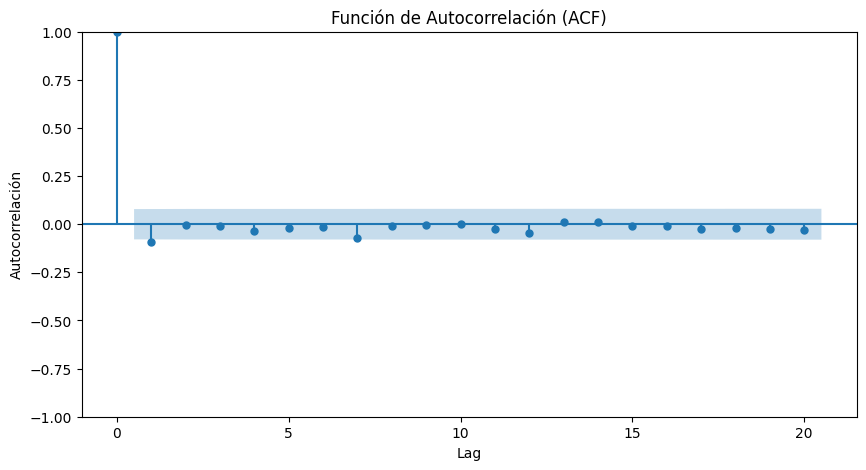

In [258]:
#Gráfica ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial

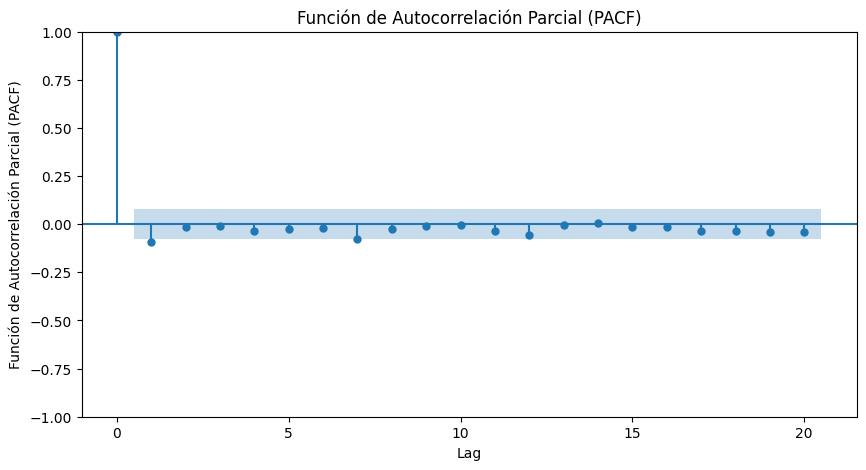

In [259]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Función de Autocorrelación Parcial (PACF)")
ax.set_title("Función de Autocorrelación Parcial (PACF)")
plt.show()

#ARIMA

In [260]:
modelo = ARIMA(df['Rendimientos_Log'].dropna(), order=(0,0,0))
resultado = modelo.fit()

print(resultado.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  620
Model:                          ARIMA   Log Likelihood                1479.744
Date:                Fri, 26 Jun 2026   AIC                          -2955.489
Time:                        19:55:34   BIC                          -2946.629
Sample:                             0   HQIC                         -2952.045
                                - 620                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.001      1.583      0.113      -0.000       0.003
sigma2         0.0005   1.52e-05     32.475      0.000       0.000       0.001
Ljung-Box (L1) (Q):                   5.05   Jarque-

In [261]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(df['Rendimientos_Log'].dropna())

print("LM Statistic:", arch_test[0])
print("p-value:", arch_test[1])

LM Statistic: 7.4363036001629945
p-value: 0.6837123437223466


In [262]:
for orden in [(0,0,0),(1,0,0),(0,0,1),(1,0,1)]:
  modelo = ARIMA(df['Rendimientos_Log'].dropna(),order=orden)
  resultado = modelo.fit()

  print(orden, resultado.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


(0, 0, 0) -2955.488553016641


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


(1, 0, 0) -2958.5332794748174


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


(0, 0, 1) -2958.6479674837083


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


(1, 0, 1) -2956.7086674137818


In [263]:
modelo = ARIMA(df['Rendimientos_Log'].dropna(),
               order=(0,0,1))

resultado = modelo.fit()

print(resultado.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:       Rendimientos_Log   No. Observations:                  620
Model:                 ARIMA(0, 0, 1)   Log Likelihood                1482.324
Date:                Fri, 26 Jun 2026   AIC                          -2958.648
Time:                        19:55:36   BIC                          -2945.359
Sample:                             0   HQIC                         -2953.482
                                - 620                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.001      1.745      0.081      -0.000       0.003
ma.L1         -0.0908      0.037     -2.451      0.014      -0.163      -0.018
sigma2         0.0005   1.56e-05     31.461      0.0

In [264]:
residuos = resultado.resid

for lag in [5,10,15,20]:
    lm, pvalue, _, _ = het_arch(residuos, nlags=lag)
    print(f"Lag={lag}: p-value={pvalue}")

Lag=5: p-value=0.4453036137547366
Lag=10: p-value=0.7816262539664955
Lag=15: p-value=0.9371938748606786
Lag=20: p-value=0.9801084831970415


In [265]:
residuos = resultado.resid

In [266]:
garch = arch_model(
    residuos,
    mean='Zero',
    vol='GARCH',
    p=1,
    q=1
)

resultado_garch = garch.fit()
print(resultado_garch.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: -1440.6759494060461
Iteration:      2,   Func. Count:     12,   Neg. LLF: 355316132.6282929
Iteration:      3,   Func. Count:     19,   Neg. LLF: -1306.9031557941144
Iteration:      4,   Func. Count:     25,   Neg. LLF: 355316132.6282929
Iteration:      5,   Func. Count:     32,   Neg. LLF: -1462.6070672629075
Iteration:      6,   Func. Count:     37,   Neg. LLF: -1478.1356394415507
Iteration:      7,   Func. Count:     43,   Neg. LLF: -1002.9093084518452
Iteration:      8,   Func. Count:     51,   Neg. LLF: -1482.3731244909238
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1489.2786509405673
            Iterations: 11
            Function evaluations: 61
            Gradient evaluations: 8
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj.

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004908. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


##Predicción de Precios

In [267]:
#Predicciones pero de los rendimientos log

predictions = resultado.forecast(steps=5)  # Predict next 5 points
print(predictions)

620    0.002066
621    0.001459
622    0.001459
623    0.001459
624    0.001459
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [268]:
ultimo_precio = precios.iloc[-1]   # Último precio conocido

precios_pred = []
precio_actual = ultimo_precio

for r in predictions:
    precio_actual = precio_actual * np.exp(r)
    precios_pred.append(precio_actual)

In [269]:
print(precios_pred)

[np.float64(201.87661511207233), np.float64(202.17134210685973), np.float64(202.46649938427996), np.float64(202.76208757251823), np.float64(203.0581073006769)]


In [270]:
precios_pred = pd.Series(precios_pred, index=predictions.index)

print(precios_pred)

620    201.876615
621    202.171342
622    202.466499
623    202.762088
624    203.058107
dtype: float64


In [271]:
#Residuos

#resultado.plot_diagnostics(figsize=(10,6))
#plt.show()

##RMSE

In [309]:
precio_inicial = df['Close'].loc[train.index[-1]]

precios_pred = [precio_inicial]

# Use 'predictions' which has 5 elements, instead of 'forecast_rend' which has 101 elements,
# to match the length of 'precios_reales' (5 elements).
for r in predictions:
    precios_pred.append(precios_pred[-1] * np.exp(r))

precios_pred = precios_pred[1:] # This will have 5 elements now, matching precios_reales

rmse = np.sqrt(mean_squared_error(precios_reales, precios_pred))
print(f"RMSE = {rmse:.2f}")

RMSE = 6.33


In [305]:
precios_reales = precios[-5:]
print(precios_reales)

Date
2026-06-22    210.360001
2026-06-23    206.100006
2026-06-24    196.639999
2026-06-25    202.990005
2026-06-26    201.460007
Name: Close, dtype: float64
[np.float64(198.87293418098625), np.float64(199.16327599300433), np.float64(199.4540416855678), np.float64(199.74523187751527), np.float64(200.03684718858878)]


In [275]:
print(len(precios_reales))
print(len(precios_pred))

5
5


##MAE

In [277]:
mae = mean_absolute_error(precios_reales, precios_pred)
print(f"MAE = {mae: .2f}")

MAE =  5.18


##Error Porcentual Absoluto Medio (MAPE)

In [278]:
# Using scikit-learn
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(precios_reales, precios_pred) * 100
print(mape)

2.512471290580862


##Auto Arima

In [279]:
Arima = auto_arima(df['Rendimientos_Log'])
print(Arima)

 ARIMA(0,0,1)(0,0,0)[0] intercept


#Monte Carlo

In [280]:
#Calcular los retornos
retornos = df['Rendimientos_Log'].dropna()
print (retornos)

Date
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
2024-01-10   -0.015367
                ...   
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
2026-06-26   -0.007566
Name: Rendimientos_Log, Length: 620, dtype: float64


In [281]:
# Ejecutar prueba en Precios Retornos
probar_estacionariedad(retornos, "Retornos")


--- Prueba ADF para: Retornos ---
Estadístico de Dickey-Fuller: -27.1992
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

In [282]:
media_retornos = retornos.mean()
print(f"La media de los retornos es: {media_retornos:.6f}")

La media de los retornos es: 0.001460


In [283]:
#Calculamos la desviación estándar
desviacion_retornos = retornos.std()
print(f"La desviación de los retornos es: {desviacion_retornos:.6f}")

La desviación de los retornos es: 0.022263


In [284]:
# Definir el número de simulaciones (escenarios) y el número de días a proyectar
num_simulaciones = 100 # Número de escenarios Monte Carlo
num_dias_a_proyectar = 100 # Número de días en el futuro para cada simulación

In [285]:
# Obtener el último precio de cierre del DataFrame
ultimo_precio_cierre = df['Close'].iloc[-1]
print("El último precio de cierre es: $", ultimo_precio_cierre)

El último precio de cierre es: $ 201.4600067138672


In [286]:
# Lista para almacenar todos los escenarios de precios simulados
monte_carlo_simulaciones = []

In [287]:
for _ in range(num_simulaciones):
    # Para cada simulación, empezar con el último precio conocido
    current_scenario_prices = [ultimo_precio_cierre]
    for _ in range(num_dias_a_proyectar):
        # Generar números aleatorios basado
        aleatorio = np.random.normal(0, 1)
        # Calcular el siguiente precio
        dt = 1/252
        precio_siguiente = current_scenario_prices[-1] * np.exp((media_retornos - 0.5 * desviacion_retornos**2) * dt + desviacion_retornos * np.sqrt(dt) * aleatorio)
        current_scenario_prices.append(precio_siguiente)
    monte_carlo_simulaciones.append(current_scenario_prices)

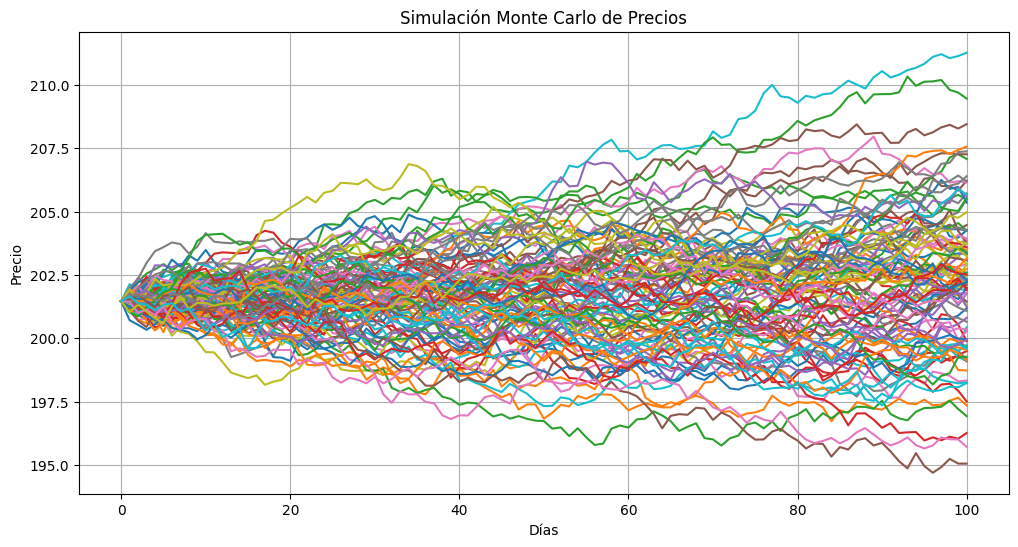

In [288]:
plt.figure(figsize=(12,6))

for simulacion in monte_carlo_simulaciones:
    plt.plot(simulacion)

plt.title('Simulación Monte Carlo de Precios')
plt.xlabel('Días')
plt.ylabel('Precio')
plt.grid(True)

plt.show()

##Predicción precio

In [289]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [290]:
# Se extrae la última columna de los precios simulados
ultima_columna = monte_carlo_simulaciones_df.iloc[:,-1]
print(ultima_columna)

0      201.460007
1      201.665912
2      201.384970
3      201.325718
4      201.109392
          ...    
96     197.910540
97     197.956901
98     198.089370
99     198.068660
100    198.231050
Name: 99, Length: 101, dtype: float64


In [291]:
#Precio de cierre número 100
precio_cien = df['Close'][-101]
print(f"El precio de cierre número cien es: $ {precio_cien: .2f}")

El precio de cierre número cien es: $  206.22


/tmp/ipykernel_11741/3328606284.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precio_cien = df['Close'][-101]


In [292]:
#Calcular Ganancias / Pérdidas

Ganancia_Pérdida = []
for precio in ultima_columna:
    ganancia_perdida = precio - precio_cien
    Ganancia_Pérdida.append(ganancia_perdida)

In [293]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T
print(Ganancia_Pérdida)

        0         1         2         3         4         5         6    \
0 -4.758118 -4.552213 -4.833154 -4.892407 -5.108733 -4.901527 -4.827156   

        7         8         9    ...       91        92        93        94   \
0 -5.153954 -5.041129 -5.486793  ... -8.475063 -8.123931 -7.887221 -8.106034   

        95        96        97        98        99        100  
0 -8.226758 -8.307585 -8.261224 -8.128754 -8.149465 -7.987074  

[1 rows x 101 columns]


In [294]:
#Contar %Ganancias y %Pérdidas si el precio de compra es lo que vale el precio de cierre número cien
if isinstance(Ganancia_Pérdida, list):
    Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T

Ganancia = (Ganancia_Pérdida > 0).sum().sum()
Perdida = (Ganancia_Pérdida < 0).sum().sum()

# Obtener el número total de simulaciones
num_simulaciones = Ganancia_Pérdida.size

# Calcular porcentajes
porcentaje_ganancia = (Ganancia / num_simulaciones) * 100
porcentaje_perdida = (Perdida / num_simulaciones) * 100

print(f"Número de simulaciones con ganancia: {Ganancia} ({porcentaje_ganancia:.2f} %)")
print(f"Número de simulaciones con pérdida: {Perdida} ({porcentaje_perdida:.2f} %)")
print(f"Número total de simulaciones: {num_simulaciones}")

Número de simulaciones con ganancia: 0 (0.00 %)
Número de simulaciones con pérdida: 101 (100.00 %)
Número total de simulaciones: 101


In [295]:
#Ganancia potencial
Ganancia_potencial = Ganancia_Pérdida.mean(axis=1).iloc[0]
print(f"Ganancia Potencial: $ {Ganancia_potencial: .2f}")

Ganancia Potencial: $ -6.39


In [296]:
#Precio Potencial
Precio_potencial = precio_cien + Ganancia_potencial
print(f"Precio Potencial: $ {Precio_potencial: .2f}")

Precio Potencial: $  199.83


##Error Cuadrático Medio (RMSE)


In [297]:
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [298]:
prediccion_mc = monte_carlo_simulaciones_df.mean(axis=1)

In [299]:
ultimos_101 = precios.iloc[-103:-2]
print(ultimos_101)

Date
2026-01-27    197.053314
2026-01-28    198.462524
2026-01-29    206.218124
2026-01-30    190.026947
2026-02-03    205.961899
                 ...    
2026-06-18    214.210007
2026-06-19    207.500000
2026-06-22    210.360001
2026-06-23    206.100006
2026-06-24    196.639999
Name: Close, Length: 101, dtype: float64


In [300]:
print(len(ultimos_101))
print(len(prediccion_mc))

101
101


In [301]:
rmse = np.sqrt(mean_squared_error(ultimos_101, prediccion_mc[0:]))
print(f"RMSE Monte Carlo: {rmse:.4f}")

RMSE Monte Carlo: 9.8130


In [302]:
rmse_porcentaje = (rmse / ultimos_101.mean()) * 100
print(f"% RMSE Monte Carlo: {rmse_porcentaje:.4f} %")

% RMSE Monte Carlo: 4.8847 %


##Error Cuadrático Medio (MAE)

In [303]:
mae = mean_absolute_error(ultimos_101, prediccion_mc)

print(f"MAE Monte Carlo: {mae:.4f}")

MAE Monte Carlo: 7.6102


##Error Porcentual Absoluto Medio (MAPE)

In [304]:
# Using scikit-learn
mape = mean_absolute_percentage_error(ultimos_101, prediccion_mc) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 3.86%
